In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv(r'phishing_site_urls.csv')
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [3]:
df.duplicated().sum()

np.int64(42150)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [5]:
from nltk.tokenize import RegexpTokenizer

In [6]:
tokenizer=RegexpTokenizer(r'[A-Za-z]+')

In [7]:
df['text_tokenized']=df.URL.map(lambda t:tokenizer.tokenize(t))

In [8]:
from nltk.stem.snowball import SnowballStemmer

In [9]:
stemmer=SnowballStemmer('english')

In [10]:
def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]



In [11]:
df['text_stemmed'] = df['text_tokenized'].map(lambda x: stem_tokens(x))
df['text']=df['text_stemmed'].map(lambda x:'-'.join(x))

In [12]:
good_sites = df[df['Label'] == 'good']
bad_sites = df[df['Label'] == 'bad']

In [13]:
all_text=' '.join(good_sites['text'].tolist())

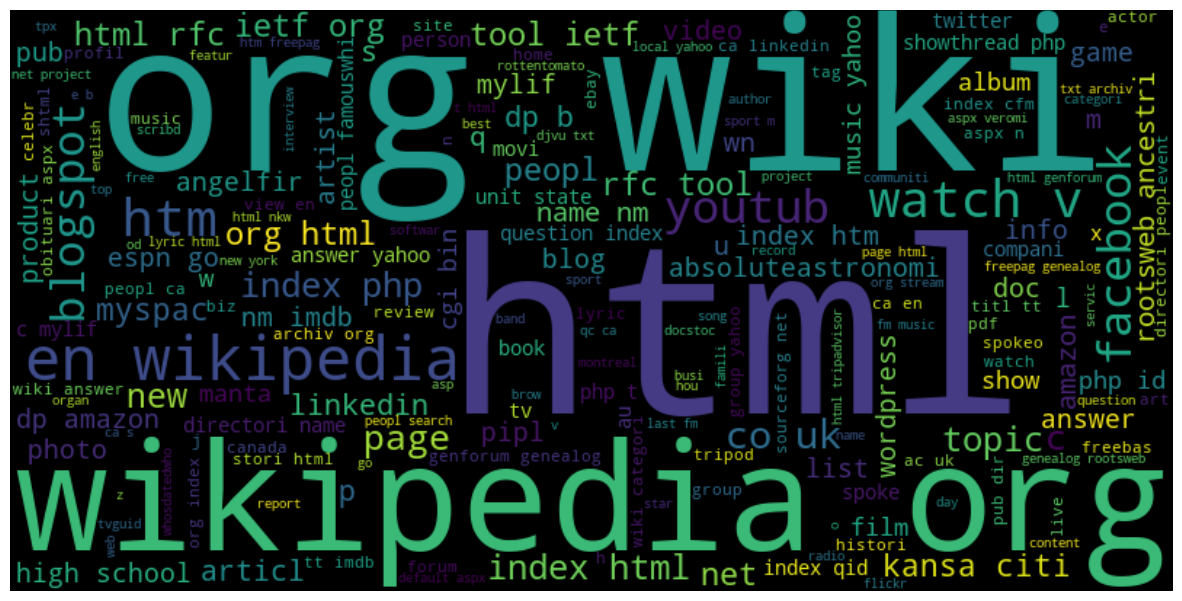

In [14]:
from matplotlib.image import interpolations_names
from wordcloud import WordCloud
wordcloud=WordCloud(width=800,height=400,background_color='black').generate(all_text)
plt.figure(figsize=(15,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [15]:
all_text=' '.join(bad_sites['text'].tolist())

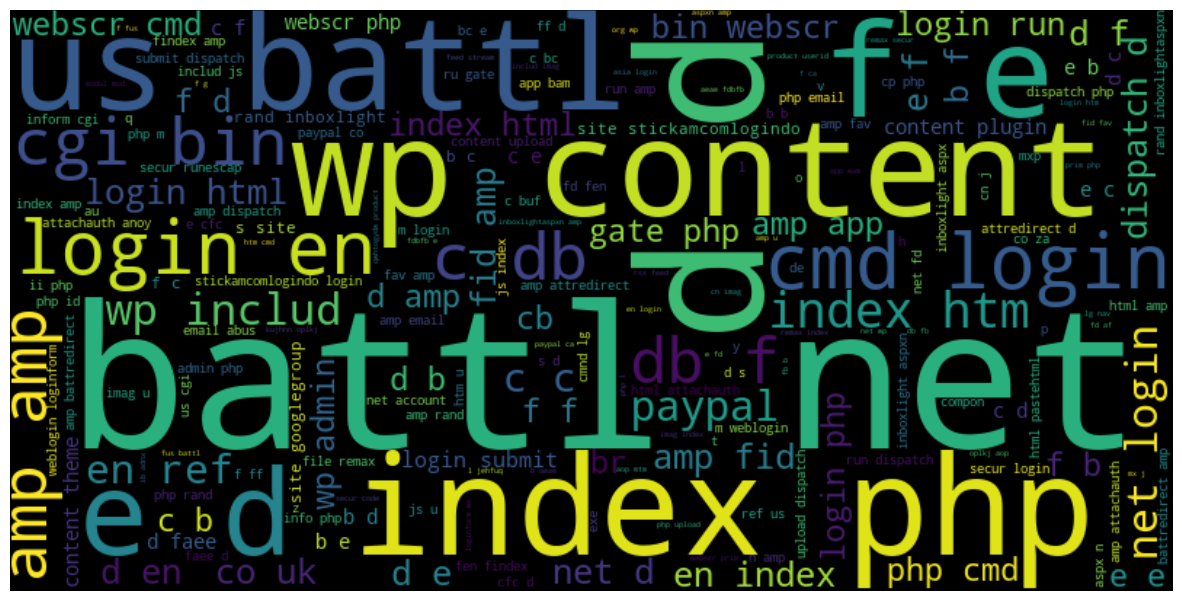

In [16]:
wordcloud=WordCloud(width=800,height=400,background_color='black').generate(all_text)
plt.figure(figsize=(15,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

In [18]:
cv=CountVectorizer()
X=cv.fit_transform(df.text)

In [19]:
X[:5].toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 350837))

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X,df.Label,test_size=0.2,random_state=42)

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
model=LogisticRegression()

In [24]:

model.fit(X_train,y_train)

c:\Users\hp\Desktop\URL Model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
model.score(X_test,y_test)

0.9643396741603714

In [26]:
from sklearn.metrics import classification_report,confusion_matrix

In [27]:
print(classification_report(y_test,model.predict(X_test)))

              precision    recall  f1-score   support

         bad       0.97      0.90      0.94     31200
        good       0.96      0.99      0.98     78670

    accuracy                           0.96    109870
   macro avg       0.97      0.95      0.96    109870
weighted avg       0.96      0.96      0.96    109870



Text(0.5, 23.52222222222222, 'Predicted')

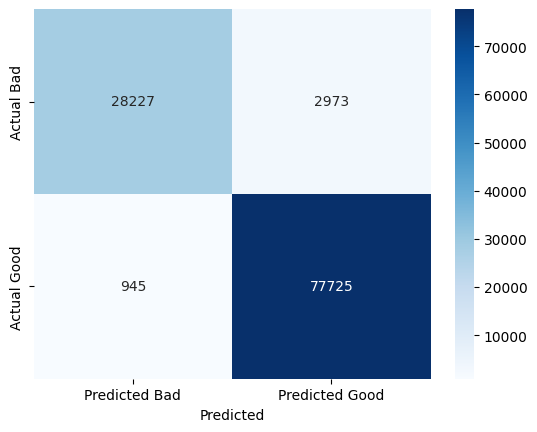

In [28]:
con_mat=pd.DataFrame(confusion_matrix(y_test,model.predict(X_test)),
                     columns=['Predicted Bad','Predicted Good'],
                        index=['Actual Bad','Actual Good'])
sns.heatmap(con_mat,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')

In [29]:
from sklearn.naive_bayes import MultinomialNB
nb_model=MultinomialNB()                                                                                                                                

In [30]:
import pickle
pickle.dump(model,open('phishing_url_model.pkl','wb'))
nb_model.fit(X_train,y_train)                                                                                                                                                                   

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [31]:
pickle.dump(cv,open('vectorizer.pkl','wb'))                                                                                                                                                                                      

In [32]:
predict_bad=['http://shadetreetechnology.com/V4/validation/a111aedc8ae390eabcfa130e041a10a4','https://support-appleld.com.secureupdate.duilawyeryork.com/ap/89e6a3b4b063b8d/?cmd=_update&dispatch=89e6a3b4b063b8d1b&locale=_','http://paypa1-confirm-account.suspicious-domain.com/verify','https://login-secure-bankofindia.verify-account.tk/security/']
predict_good=['https://www.google.com/','https://www.github.com/']

In [33]:
predict_bad=cv.transform(predict_bad)
predict_good=cv.transform(predict_good)

In [34]:
model.predict(predict_bad)


array(['bad', 'bad', 'bad', 'bad'], dtype=object)

In [35]:
model.predict(predict_good)

array(['bad', 'bad'], dtype=object)

In [36]:
nb_model.predict(predict_bad)

array(['bad', 'bad', 'bad', 'bad'], dtype='<U4')

In [37]:
from sklearn.metrics import accuracy_score, classification_report
print("LogReg accuracy:", accuracy_score(y_test, model.predict(X_test)))

print(classification_report(y_test, model.predict(X_test)))

LogReg accuracy: 0.9643396741603714
              precision    recall  f1-score   support

         bad       0.97      0.90      0.94     31200
        good       0.96      0.99      0.98     78670

    accuracy                           0.96    109870
   macro avg       0.97      0.95      0.96    109870
weighted avg       0.96      0.96      0.96    109870

